# RLSSM Restless Learner Tutorial: One Learner, Two Decision Parameters

The [basic](rlssm_basic.ipynb) and [advanced](rlssm_advanced.ipynb) tutorials each
let a learner shape **one** part of the decision: the trial-wise drift rate `v`. The
other decision parameters — boundary separation `a`, starting point `z`, non-decision
time `t`, and the angle/collapse parameter `theta` — stayed fixed within a
participant.

Here we lift that restriction. A single Rescorla–Wagner learner drives **two**
decision parameters at once:

- its value **difference** sets the drift `v` (as before), and
- its total value **magnitude** sets the angle parameter `theta`, so the decision
  boundary collapses at a rate that itself changes with learning.

The one new ingredient is `computed_param_mapping`, which routes each of the learner's
outputs to a named SSM parameter. Everything downstream — the
`RLSSMConfig.from_ssms_model` bridge, the hierarchical fit, recovery, and
`mode="ppc"` checks — is identical to the earlier tutorials.

> **Where this sits in the suite:** start with
> [RLSSM basics](rlssm_basic.ipynb) if the bridge or hierarchical fit is new, and see
> [building a custom model](rlssm_advanced.ipynb) for a task environment with several
> conditions. The last tutorial,
> [HSSM-native custom model registration](rlssm_hssm_custom_models.ipynb), shows the
> shorter registry-based path.

## 1. One learning process, two computed parameters, two timescales

An RLSSM couples a slow process and a fast one. On each trial:

1. the **learner** holds a value state (here two Q-values) that changes slowly across
   trials as feedback arrives; and
2. the **decision model** turns the current decision parameters into a single choice
   and response time within that trial.

In the basic tutorial the learner computed only `v`. A learning process may instead
declare **several** computed outputs. Our learner declares two:

$$
v_t = (Q_{1,t}-Q_{0,t})\,\text{scaler}, \qquad
\theta_t = \text{urgency\_gain}\,(Q_{0,t}+Q_{1,t}).
$$

`computed_param_mapping = {"drift": "v", "urgency": "theta"}` connects the learner's
local output names (`drift`, `urgency`) to the SSM's parameter names (`v`, `theta`).
Because both `v` and `theta` are now computed every trial, they are **not** free
parameters to estimate — HSSM recovers only the learner's parameters
(`rl_alpha`, `scaler`, `urgency_gain`) and the remaining fixed SSM parameters
(`a`, `z`, `t`).

**Why couple `theta` to value at all?** The angle model's boundary starts at `a` and
narrows over the course of a single decision; larger `theta` makes it narrow faster,
so evidence is required to accumulate less before a response is committed. Tying
`theta` to total value $Q_0+Q_1$ makes this collapse **sharpen as the participant
learns** — an illustrative value-dependent urgency signal, not a canonical
psychological mechanism. The two timescales interact: across trials, learning raises
$\theta_t$; within a trial, a higher $\theta_t$ collapses the boundary sooner.

## 2. Setup

In [1]:
import logging
import os
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm

import hssm
import ssms.rl as rl
from ssms.rl.env import Bandit

warnings.filterwarnings("ignore")
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)

# HSSM and the JAX learner must agree on numerical precision.
hssm.set_floatX("float32", update_jax=True)
RANDOM_SEED = 20260706

Setting PyTensor floatX type to float32.


Setting "jax_enable_x64" to False. If this is not intended, please set `jax` to False.


### 2.1 Simulation and inference scale

The notebook has two scales. The short doc-scale run checks that every cell executes.
The committed `FULL_RUN=1` output uses more participants and many more trials because
VI is fast enough to make the richer recovery demonstration practical.

In [2]:
FULL_RUN = os.environ.get("FULL_RUN", "0") == "1"

N_PARTICIPANTS = 20 if FULL_RUN else 8
N_TRIALS = 1000 if FULL_RUN else 300
N_VI_ITER = 10_000 if FULL_RUN else 3_000
N_DRAWS = 500
N_PPC_DRAWS = 20 if FULL_RUN else 8
VI_LEARNING_RATE = 0.01
VI_START_SIGMA = 0.01

INITIAL_Q = 0.20
REWARD_PROBS = [0.7, 0.3]   # option 0 (label -1) is the high-reward option
RESPONSE_LABELS = [-1, 1]   # angle SSM boundary labels

print(
    f"scale: {N_PARTICIPANTS} participants x {N_TRIALS} trials | "
    f"ADVI iterations: {N_VI_ITER}"
)

scale: 20 participants x 1000 trials | ADVI iterations: 10000


## 3. Write the dual-output learning process

The learner is an ordinary two-armed Rescorla–Wagner rule with one twist: it returns
**two** computed quantities each trial instead of one. Three properties make the
multi-output contract explicit:

- `computed_params = ["drift", "urgency"]` — the learner produces two trial-wise
  outputs. These are *local* names; the model configuration will map them onto SSM
  parameters.
- `free_params = ["rl_alpha", "scaler", "urgency_gain"]` — the participant parameters
  supplied during simulation and estimated by HSSM. `scaler` converts the value
  *difference* into drift; `urgency_gain` converts the value *sum* into the angle
  parameter.
- `supports_gradient = True` with a `"jax"` backend — HSSM differentiates through the
  learner during NUTS sampling, so both a NumPy path (for ordinary simulation) and a
  JAX path (for gradients) are implemented.

`compute_*` runs **before** the decision and reads the current Q-values; `update_*`
runs **after** feedback arrives and adjusts the chosen option's value. The simulator
injects the zero-based `choice` into the context after the SSM responds, and the
`Bandit` environment supplies `feedback`.

In [3]:
class DualOutputRWLearner:
    "Rescorla-Wagner learner emitting drift (-> v) and urgency (-> theta)."

    def __init__(self, initial_q=0.5, feedback_field="feedback"):
        self._initial_q = initial_q
        self._feedback_field = feedback_field

    @property
    def computed_params(self):
        # Two trial-wise outputs; mapped to SSM names in the ModelConfig.
        return ["drift", "urgency"]

    @property
    def free_params(self):
        return ["rl_alpha", "scaler", "urgency_gain"]

    @property
    def param_bounds(self):
        return {
            "rl_alpha": (0.0, 1.0),
            "scaler": (0.001, 10.0),
            "urgency_gain": (0.0, 0.6),
        }

    @property
    def default_params(self):
        return {"rl_alpha": 0.2, "scaler": 2.0, "urgency_gain": 0.3}

    @property
    def available_backends(self):
        return ("python", "jax")

    @property
    def supports_gradient(self):
        return True

    @property
    def required_context_fields(self):
        # choice is injected by the simulator; feedback comes from the bandit.
        return ["choice", self._feedback_field]

    def init_state(self):
        return {"q_values": np.full(2, self._initial_q, dtype=np.float64)}

    def init_jax_state(self):
        import jax.numpy as jnp

        return {"q_values": jnp.full((2,), self._initial_q)}

    def compute_python(self, state, params, context):
        q = state["q_values"]
        # difference -> drift; sum -> urgency (both before the value update)
        return {
            "drift": float((q[1] - q[0]) * params["scaler"]),
            "urgency": float(params["urgency_gain"] * (q[0] + q[1])),
        }

    def compute_jax(self, state, params, context):
        q = state["q_values"]
        return {
            "drift": (q[1] - q[0]) * params["scaler"],
            "urgency": params["urgency_gain"] * (q[0] + q[1]),
        }

    def update_python(self, state, params, context):
        choice = int(context["choice"])
        feedback = float(context[self._feedback_field])
        q = np.asarray(state["q_values"], dtype=np.float64).copy()
        q[choice] += params["rl_alpha"] * (feedback - q[choice])
        return {"q_values": q}

    def update_jax(self, state, params, context):
        choice = context["choice"]
        feedback = context[self._feedback_field]
        q = state["q_values"]
        return {"q_values": q.at[choice].add(params["rl_alpha"] * (feedback - q[choice]))}

## 4. Assemble the model and route the two outputs

`ModelConfig` binds the learner to a registered decision process (`"angle"`) and a
task environment. The `Bandit.bernoulli` factory builds a two-armed Bernoulli bandit
whose response labels `[-1, 1]` match the angle SSM's two boundaries. The crucial
argument is `computed_param_mapping`: it declares that the learner's `drift` output
supplies the SSM's `v` and its `urgency` output supplies `theta`.

`validate()` checks the cross-component contract; `assemble(backend="jax")` resolves
the learner/SSM handshake. The two assertions below are the heart of this tutorial:
after assembly, exactly `{"v", "theta"}` are learner-computed, and a gradient is
available for NUTS.

In [4]:
ssms_config = rl.ModelConfig(
    model_name="DualOutput_RW_Angle",
    description="RW learner driving both drift (v) and the angle parameter (theta).",
    decision_process="angle",
    learning_process=DualOutputRWLearner(initial_q=INITIAL_Q),
    task_environment=Bandit.bernoulli(
        probabilities=REWARD_PROBS, response_labels=RESPONSE_LABELS
    ),
    computed_param_mapping={"drift": "v", "urgency": "theta"},
)

ssms_config.validate()
assembled = ssms_config.assemble(backend="jax")
print("free parameters:", ssms_config.list_params)
print("learner-computed SSM parameters:", assembled.computed_params)
print("gradient support:", assembled.gradient)
assert set(assembled.computed_params) == {"v", "theta"}
assert assembled.gradient == "available"

free parameters: ['rl_alpha', 'scaler', 'urgency_gain', 'a', 'z', 't']
learner-computed SSM parameters: ['v', 'theta']
gradient support: available


Because this is a recovery tutorial, we simulate from known group means with genuine
participant differences, then try to recover them. Only the **six free** parameters
appear here — `rl_alpha`, `scaler`, `urgency_gain`, `a`, `z`, `t`. The two computed
parameters `v` and `theta` are produced by the learner every trial and must **never**
be placed in the simulation `theta`; doing so would double-specify them and break the
bridge.

Each parameter gets its own between-participant spread. A bounded quantity such as `z`
varies far less than the drift `scaler`, so a single flat SD would be inappropriate.
The helper draws one value per participant, clips it to the supported range, and
returns both the array-valued `theta` for the simulator and a table of truths.

In [5]:
GROUP_THETA = {
    "rl_alpha": 0.08,       # learning rate (small -> a visibly gradual curve)
    "scaler": 2.50,         # value difference -> drift gain
    "urgency_gain": 0.30,   # value sum -> angle/collapse gain
    "a": 1.20,              # boundary separation
    "z": 0.50,              # starting-point bias (0.5 = unbiased)
    "t": 0.25,              # non-decision time (seconds)
}
# Modest, parameter-specific between-participant SDs. These are deliberately
# tighter than in the earlier tutorials: the urgency->theta coupling makes the
# hierarchical posterior funnel-prone (see the sampling note in Section 8), and
# keeping the population compact yields well-behaved geometry.
SDS = {
    "rl_alpha": 0.03,
    "scaler": 0.30,
    "urgency_gain": 0.05,
    "a": 0.12,
    "z": 0.04,
    "t": 0.03,
}
BOUNDS = {
    "rl_alpha": (0.01, 1.0),
    "scaler": (0.1, 5.0),
    "urgency_gain": (0.0, 0.6),
    "a": (0.3, 2.5),
    "z": (0.1, 0.9),
    "t": (0.05, 1.0),
}
LIST_PARAMS = list(GROUP_THETA)


def make_participant_theta(group_theta, sds, bounds, n_participants, rng):
    "Draw bounded participant parameters around known group means."
    theta = {
        name: np.clip(
            rng.normal(group_theta[name], sds[name], n_participants), *bounds[name]
        )
        for name in group_theta
    }
    true = pd.DataFrame(theta)
    true.index.name = "participant_id"
    return theta, true


rng = np.random.default_rng(RANDOM_SEED)
theta_arrays, true_params = make_participant_theta(
    GROUP_THETA, SDS, BOUNDS, N_PARTICIPANTS, rng
)
true_params.round(3)

,rl_alpha,scaler,urgency_gain,a,z,t
participant_id,,,,,,
0,0.084,2.769,0.419,1.242,0.544,0.253
1,0.070,2.765,0.305,1.134,0.419,0.270
2,0.070,2.290,0.284,1.164,0.444,0.257
3,0.081,2.615,0.202,1.186,0.493,0.265
4,0.019,2.847,0.259,1.014,0.424,0.248
5,0.102,1.935,0.296,1.013,0.457,0.246
6,0.088,2.375,0.260,1.203,0.519,0.289
7,0.080,2.779,0.275,1.067,0.505,0.239
8,0.083,3.023,0.269,1.215,0.475,0.264


One simulator call runs the full trial loop — compute `v` and `theta`, simulate the
choice and RT, deliver feedback, update the Q-values — for every participant.
`validate_data(...).raise_for_errors()` then checks the real dataframe (required
columns, balanced participant panels, valid responses, usable context) so any data
problem surfaces here rather than deep inside the likelihood.

In [6]:
data = rl.Simulator(ssms_config).simulate(
    theta=theta_arrays,
    n_trials=N_TRIALS,
    n_participants=N_PARTICIPANTS,
    random_state=RANDOM_SEED,
)
ssms_config.validate_data(data).raise_for_errors()

print("rows:", len(data), "| columns:", list(data.columns))
data.head()

rows: 20000 | columns: ['participant_id', 'trial_id', 'rt', 'response', 'feedback']


,participant_id,trial_id,rt,response,feedback
0,0,0,0.520416,1,1.0
1,0,1,0.640713,-1,0.0
2,0,2,1.404233,1,0.0
3,0,3,0.800949,-1,1.0
4,0,4,1.071404,1,0.0


## 5. The restless signature: latent `v` and `theta` paths

Before fitting, it helps to *see* the two coupled parameters the learner produced. We
replay each participant's own observed choices and feedback through the learning rule
to reconstruct the pre-decision `v` and `theta` that drove every trial, then average
these paths across participants in trial bins.

This is the "restless" signature of the model: as the good option is discovered, the
value difference grows (drift moves away from zero) **and** the total value grows
(the angle parameter `theta` climbs, so the boundary collapses faster). A single
learning process is moving two decision parameters on the slow, across-trial
timescale.

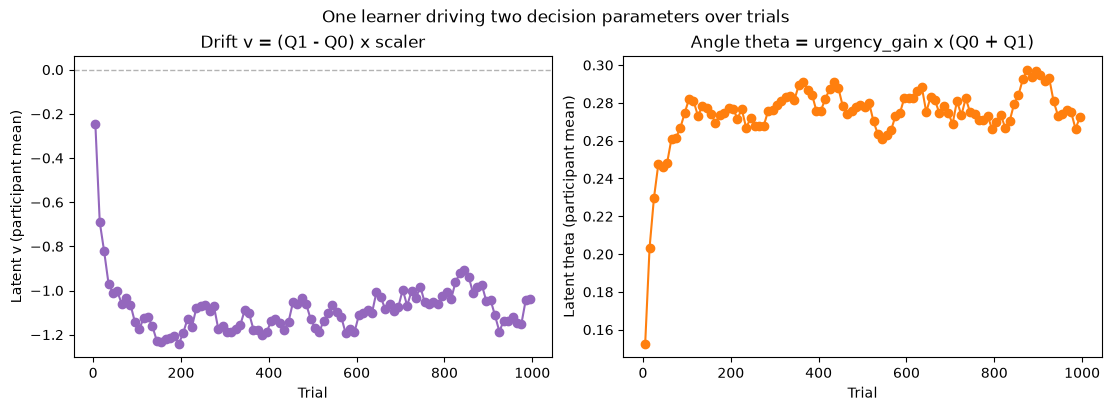

theta rises by +0.120
v moves by     -0.793


In [7]:
def reconstruct_latent_paths(dataframe, true_values, initial_q=INITIAL_Q):
    "Replay observed choices/feedback per participant to recover pre-decision v, theta."
    learner = DualOutputRWLearner(initial_q=initial_q)
    records = []
    for participant_id, trials in dataframe.groupby("participant_id", observed=True):
        trials = trials.sort_values("trial_id")
        params = {
            name: float(true_values.loc[participant_id, name])
            for name in ["rl_alpha", "scaler", "urgency_gain"]
        }
        state = learner.init_state()
        for trial_number, (_, row) in enumerate(trials.iterrows()):
            computed = learner.compute_python(state, params, {})
            records.append(
                {
                    "participant_id": participant_id,
                    "trial": trial_number,
                    "v": computed["drift"],
                    "theta": computed["urgency"],
                }
            )
            choice = 0 if int(row["response"]) == -1 else 1
            state = learner.update_python(
                state, params, {"choice": choice, "feedback": float(row["feedback"])}
            )
    return pd.DataFrame(records)


BIN_SIZE = 10
latent = reconstruct_latent_paths(data, true_params)
latent["trial_bin"] = (latent["trial"] // BIN_SIZE) * BIN_SIZE
trajectory = latent.groupby("trial_bin")[["v", "theta"]].mean()
centers = trajectory.index + BIN_SIZE / 2

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(centers, trajectory["v"], "o-", color="tab:purple")
axes[0].axhline(0.0, color="0.7", ls="--", lw=1)
axes[0].set_title("Drift v = (Q1 - Q0) x scaler")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Latent v (participant mean)")
axes[1].plot(centers, trajectory["theta"], "o-", color="tab:orange")
axes[1].set_title("Angle theta = urgency_gain x (Q0 + Q1)")
axes[1].set_xlabel("Trial")
axes[1].set_ylabel("Latent theta (participant mean)")
fig.suptitle("One learner driving two decision parameters over trials")
plt.show()

print(f"theta rises by {trajectory['theta'].iloc[-1] - trajectory['theta'].iloc[0]:+.3f}")
print(f"v moves by     {trajectory['v'].iloc[-1] - trajectory['v'].iloc[0]:+.3f}")

## 6. Bridge the model into HSSM

The bridge call is identical to the preset and custom-model tutorials. It inspects the
assembled `ssms.rl` model and builds HSSM metadata for the free parameters, their
bounds, the JAX learning function, and the trial-level context.

The assertion is what makes this notebook different from the earlier ones: **both** `v`
and `theta` are reported as learner-computed, so neither may appear among the sampled
parameters.

In [8]:
model_config = hssm.rl.RLSSMConfig.from_ssms_model(ssms_config)

print("list_params (free):", model_config.list_params)
print("computed by learner:", set(model_config.ssm_logp_func.computed))
assert set(model_config.ssm_logp_func.computed) == {"v", "theta"}
assert "v" not in model_config.list_params
assert "theta" not in model_config.list_params

list_params (free): ['rl_alpha', 'scaler', 'urgency_gain', 'a', 'z', 't']
computed by learner: {'v', 'theta'}


## 7. Specify hierarchical priors and build the model

As in the earlier tutorials, every free parameter gets a group intercept and a
participant deviation:

```
rl_alpha ~ 1 + (1 | participant_id)
```

This example uses **informative priors**. That is deliberate. The model is more
strongly coupled than the single-output tutorials: `scaler` controls how Q-value
differences become drift, while `urgency_gain` controls how the same Q-values become
the angle parameter. Weak priors leave several tradeoffs open, and those tradeoffs are
hard for approximate inference.

The intercept priors are centered near plausible values used to generate the synthetic
data. The participant deviations have mean **0**, so the intercept owns the group
location, and each parameter receives its own `HalfNormal` scale based on the simulated
amount of individual variation. This keeps the example focused on the RLSSM mechanics
rather than on a deliberately difficult prior-sensitivity exercise.

In [9]:
def participant_effect_prior(name):
    "Mean-zero participant deviations with parameter-specific variation."
    return {
        "name": "Normal",
        "mu": 0,
        "sigma": {"name": "HalfNormal", "sigma": SDS[name] * 1.5},
    }


def hierarchical_param(name, lower, upper, mu, sigma):
    "Group intercept plus mean-zero participant deviations."
    return hssm.Param(
        name,
        formula=f"{name} ~ 1 + (1|participant_id)",
        prior={
            "Intercept": hssm.Prior(
                "TruncatedNormal",
                lower=lower,
                upper=upper,
                mu=mu,
                sigma=max(sigma, 0.03),
            ),
            "1|participant_id": participant_effect_prior(name),
        },
    )

The constructor receives the trial data and bridged config. `p_outlier=0` and
`lapse=None` disable mixture components to keep the tutorial focused. Only the six free
parameters are included — `v` and `theta` are absent because the learner computes them.

For this tutorial we fit with variational inference rather than NUTS. The model object
is the same `hssm.RLSSM`; only the inference method changes in the next section.

In [10]:
model = hssm.RLSSM(
    data=data,
    model_config=model_config,
    p_outlier=0,
    lapse=None,
    process_initvals=False,
    include=[
        hierarchical_param("rl_alpha", 0.01, 1.0, GROUP_THETA["rl_alpha"], SDS["rl_alpha"] * 2),
        hierarchical_param("scaler", 0.1, 5.0, GROUP_THETA["scaler"], SDS["scaler"] * 2),
        hierarchical_param(
            "urgency_gain", 0.0, 0.6,
            GROUP_THETA["urgency_gain"], SDS["urgency_gain"] * 2,
        ),
        hierarchical_param("a", 0.3, 2.5, GROUP_THETA["a"], SDS["a"] * 2),
        hierarchical_param("z", 0.1, 0.9, GROUP_THETA["z"], SDS["z"] * 2),
        hierarchical_param("t", 0.05, 1.0, GROUP_THETA["t"], SDS["t"] * 2),
    ],
)

print("participants:", model.n_participants, "| trials/participant:", model.n_trials)
print("free parameters:", list(model.params))
assert "v" not in model.params
assert "theta" not in model.params

You supplied a model 'DualOutput_RW_Angle', which is currently not supported in the ssm_simulators package. An error will be thrown when sampling from the random variable or when using any posterior or prior predictive sampling methods.


Model initialized successfully.


participants: 20 | trials/participant: 1000
free parameters: ['rl_alpha', 'scaler', 'urgency_gain', 'a', 'z', 't']


Printing the model is a quick structural check. Every free parameter should have an
intercept and a participant term, while both `v` and `theta` are absent — the learner
supplies them trial by trial.

In [11]:
print(model.model)

       Formula: c(rt, response) ~ 1 + (1|participant_id)
                scaler ~ 1 + (1|participant_id)
                urgency_gain ~ 1 + (1|participant_id)
                a ~ 1 + (1|participant_id)
                z ~ 1 + (1|participant_id)
                t ~ 1 + (1|participant_id)
        Family: SSM Family
          Link: rl_alpha = identity
                scaler = identity
                urgency_gain = identity
                a = identity
                z = identity
                t = identity
  Observations: 20000
        Priors: 
    target = rl_alpha
        Common-level effects
            Intercept ~ TruncatedNormal(lower: 0.009999999776482582, upper: 1.0, mu: 0.07999999821186066,
                sigma: 0.05999999865889549)
        
        
        Group-level effects
            1|participant_id ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 0.04500000178813934))
    target = scaler
        Common-level effects
            scaler_Intercept ~ TruncatedNormal(lower: 0.100

## 8. Approximate the posterior with variational inference

The previous tutorials used MCMC: the sampler constructs a Markov chain whose draws
approximate the exact Bayesian posterior. MCMC is often the safest default when the
posterior geometry is complicated, but it can be slow, and this restless model is a
case where the geometry is genuinely difficult. One learner feeds two decision
parameters, producing tradeoffs among `rl_alpha`, `scaler`, `urgency_gain`, and the
SSM parameters.

Here we use **variational inference (VI)**. VI turns Bayesian inference into an
optimization problem. Instead of drawing a long Markov chain, we choose a simpler
family of probability distributions and optimize the member of that family that is
closest to the true posterior according to an objective called the evidence lower
bound (ELBO). After optimization, we draw samples from the optimized approximation.
Those samples behave like posterior draws for plotting and posterior predictive checks,
but they are draws from an **approximate** posterior, not from an asymptotically exact
MCMC chain.

HSSM exposes VI through `model.vi(...)`, using PyMC's native VI machinery underneath.
That means the same HSSM model object can be fitted with MCMC or VI. This includes
RLSSM models: the JAX-differentiable learner still provides gradients, and PyMC can
optimize a variational approximation to the posterior over the free parameters.

For this demonstration we use mean-field ADVI with an Adagrad-window optimizer. The
starts are intentionally informative: intercepts begin near the generative values,
participant deviations begin at zero, and the initial variational standard deviation
is small. Those choices make the optimization stable for this coupled model and keep
the example focused on how VI can be used with an RLSSM.

Finished [100%]: Average Loss = 13,221


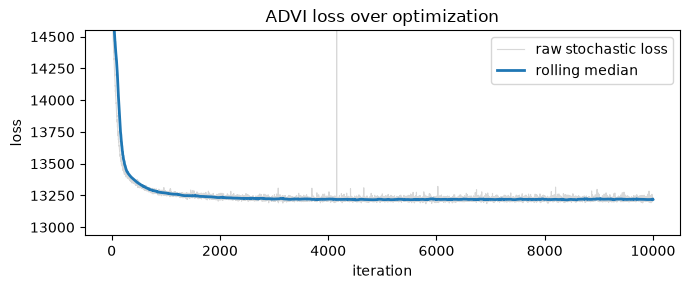

<xarray.DataTree>
Group: /
├── Group: /posterior
│       Dimensions:                                (chain: 1, draw: 500,
│                                                   participant_id__factor_dim: 20,
│                                                   rl_alpha_1|participant_id__factor_dim: 20)
│       Coordinates:
│         * chain                                  (chain) int64 8B 0
│         * draw                                   (draw) int64 4kB 0 1 2 ... 498 499
│         * participant_id__factor_dim             (participant_id__factor_dim) <U2 160B ...
│         * rl_alpha_1|participant_id__factor_dim  (rl_alpha_1|participant_id__factor_dim) <U2 160B ...
│       Data variables: (12/24)
│           rl_alpha_Intercept                     (chain, draw) float32 2kB 0.08195 ...
│           z_1|participant_id_sigma               (chain, draw) float32 2kB 0.03694 ...
│           urgency_gain_1|participant_id_offset   (chain, draw, participant_id__factor_dim) float32 40kB ...
│           urgency_gain_1|participant_id          (chain, draw, participant_id__factor_dim) float32 40kB ...
│           t_1|participant_id_offset              (chain, draw, participant_id__factor_dim) float32 40kB ...
│           z_1|participant_id_offset              (chain, draw, participant_id__factor_dim) float32 40kB ...
│           ...                                     ...
│           t_1|participant_id                     (chain, draw, participant_id__factor_dim) float32 40kB ...
│           z_1|participant_id                     (chain, draw, participant_id__factor_dim) float32 40kB ...
│           scaler_1|participant_id                (chain, draw, participant_id__factor_dim) float32 40kB ...
│           a_1|participant_id_offset              (chain, draw, participant_id__factor_dim) float32 40kB ...
│           t_Intercept                            (chain, draw) float32 2kB 0.2562 ....
│           a_Intercept                            (chain, draw) float32 2kB 1.13 ......
│       Attributes:
│           created_at:                 2026-07-06T18:53:35.026689+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
├── Group: /sample_stats
│       Attributes:
│           created_at:                 2026-07-06T18:53:35.031282+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.2.0
│           creation_library_language:  Python
│           inference_library:          pymc
│           inference_library_version:  6.0.1
│           sample_dims:                ['chain', 'draw']
└── Group: /observed_data
        Dimensions:                  (__obs__: 20000, rt,response_extra_dim_0: 2)
        Coordinates:
          * __obs__                  (__obs__) int64 160kB 0 1 2 3 ... 19997 19998 19999
          * rt,response_extra_dim_0  (rt,response_extra_dim_0) int64 16B 0 1
        Data variables:
            rt,response              (__obs__, rt,response_extra_dim_0) float32 160kB ...
        Attributes:
            created_at:                 2026-07-06T18:53:35.031920+00:00
            creation_library:           ArviZ
            creation_library_version:   1.2.0
            creation_library_language:  Python
            inference_library:          pymc
            inference_library_version:  6.0.1
            sample_dims:                []

In [12]:
def interval_start(value, lower, upper):
    "Transform a bounded natural-scale value to PyMC's interval space."
    clipped = float(np.clip(value, lower + 1e-4, upper - 1e-4))
    return np.asarray(np.log((clipped - lower) / (upper - clipped)), dtype="float32")


def make_vi_start(model, group_theta, sds, bounds, n_participants):
    "Finite, informative start values for ADVI's transformed PyMC variables."
    start = model.pymc_model.initial_point()
    for name, value in group_theta.items():
        interval_name = f"{name}_Intercept_interval__"
        if interval_name in start:
            start[interval_name] = interval_start(value, *bounds[name])

        sigma_name = f"{name}_1|participant_id_sigma_log__"
        if sigma_name in start:
            start[sigma_name] = np.asarray(np.log(max(sds[name], 1e-3)), dtype="float32")

        offset_name = f"{name}_1|participant_id_offset"
        if offset_name in start:
            start[offset_name] = np.zeros(n_participants, dtype="float32")
    return start


def make_start_sigma(start, sigma=VI_START_SIGMA):
    "Small initial ADVI uncertainty around the explicit start point."
    return {
        name: np.full_like(np.asarray(value), sigma, dtype="float32")
        for name, value in start.items()
    }


vi_start = make_vi_start(model, GROUP_THETA, SDS, BOUNDS, N_PARTICIPANTS)
vi_start_sigma = make_start_sigma(vi_start)

idata = model.vi(
    method="advi",
    niter=N_VI_ITER,
    draws=N_DRAWS,
    progressbar=False,
    random_seed=RANDOM_SEED,
    start=vi_start,
    start_sigma=vi_start_sigma,
    ignore_mcmc_start_point_defaults=True,
    obj_optimizer=pm.adagrad_window(learning_rate=VI_LEARNING_RATE),
)

loss = np.asarray(model.vi_approx.hist, dtype=float)
rolling_loss = pd.Series(loss).rolling(100, min_periods=1).median()

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(loss, color="0.75", lw=0.8, alpha=0.6, label="raw stochastic loss")
ax.plot(rolling_loss, color="tab:blue", lw=2, label="rolling median")
lo, hi = np.nanpercentile(loss, [1, 99])
ax.set_ylim(lo * 0.98, hi * 1.05)
ax.set_title("ADVI loss over optimization")
ax.set_xlabel("iteration")
ax.set_ylabel("loss")
ax.legend()
fig.tight_layout()
plt.show()

idata

## 9. Parameter recovery

We recover the **six free** parameters only. `v` and `theta` are not estimated — they
are deterministic functions of the learner's state — so they never appear in the
recovery plots. As before we use two views:

1. group intercepts versus the realized sample mean of the simulated participants; and
2. each participant's intercept-plus-deviation estimate versus their true value.

All six parameters use identity links, so no inverse transformation is needed.

The group comparison deserves one extra note. We generated participant values from
population means, but with a finite number of participants the realized sample mean is
not exactly equal to the population mean. The fitted intercept is informed by the
participants we actually simulated, so the plot below marks the realized participant
mean as the primary recovery target and the population mean as a secondary reference.
This distinction matters more here because ADVI intervals are often narrow.

> **What this section is and isn't testing.** The purpose of this tutorial is to show
> that HSSM can *specify and fit* a flexible RLSSM in which one learner drives multiple
> decision parameters — that machinery works exactly as in the earlier tutorials.
> **How well each parameter can be recovered is a separate question**, and it is a
> property of the *model and design*, not of HSSM. VI gives us a fast approximation
> that is useful for demonstration and PPCs, but its uncertainty intervals should not
> be read as carefully calibrated MCMC intervals.

In [13]:
def posterior_dataset(idata):
    "Return the posterior as an xarray Dataset for both PyMC 5 and PyMC 6 outputs."
    posterior = idata.posterior
    return posterior.to_dataset() if hasattr(posterior, "to_dataset") else posterior


def group_recovery(idata, population_group, true_values):
    "Plot group intercept posteriors against realized and population means."
    names = [f"{name}_Intercept" for name in LIST_PARAMS]
    summary = az.summary(
        idata, var_names=names, kind="stats",
        ci_kind="hdi", ci_prob=0.94, round_to="none",
    )
    summary.index = LIST_PARAMS
    summary["population_mean"] = [population_group[name] for name in LIST_PARAMS]
    summary["realized_mean"] = true_values[LIST_PARAMS].mean().to_numpy()

    fig, ax = plt.subplots(figsize=(8, 4.5))
    y = np.arange(len(LIST_PARAMS))
    ax.errorbar(
        summary["mean"],
        y,
        xerr=[
            summary["mean"] - summary["hdi94_lb"],
            summary["hdi94_ub"] - summary["mean"],
        ],
        fmt="o",
        capsize=4,
        label="VI posterior approximation (94% HDI)",
    )
    ax.scatter(
        summary["realized_mean"], y, color="crimson", marker="D", zorder=5,
        label="realized participant mean",
    )
    ax.scatter(
        summary["population_mean"], y, color="0.35", marker="x", zorder=5,
        label="population mean used for simulation",
    )
    ax.set_yticks(y)
    ax.set_yticklabels(LIST_PARAMS)
    ax.invert_yaxis()
    ax.set_title("Group-level recovery with ADVI")
    ax.legend()
    fig.tight_layout()
    plt.show()
    return summary


def participant_recovery(idata, true_values):
    "Plot true versus recovered participant values for all six free parameters."
    post = posterior_dataset(idata)
    fig, axes = plt.subplots(2, 3, figsize=(12, 7), constrained_layout=True)
    correlations = {}

    for ax, name in zip(axes.ravel(), LIST_PARAMS):
        effect = post[f"{name}_1|participant_id"]
        participant_dim = [
            dim for dim in effect.dims if dim not in ("chain", "draw")
        ][0]
        draws = post[f"{name}_Intercept"] + effect
        recovered = draws.mean(("chain", "draw")).values
        lower = draws.quantile(0.03, ("chain", "draw")).values
        upper = draws.quantile(0.97, ("chain", "draw")).values
        participant_ids = [int(value) for value in effect[participant_dim].values]
        truth = true_values.loc[participant_ids, name].values
        correlation = float(np.corrcoef(truth, recovered)[0, 1])
        correlations[name] = correlation

        ax.errorbar(
            truth,
            recovered,
            yerr=[recovered - lower, upper - recovered],
            fmt="o",
            ecolor="0.7",
            capsize=3,
        )
        limits = [
            min(truth.min(), recovered.min()) - 0.03,
            max(truth.max(), recovered.max()) + 0.03,
        ]
        ax.plot(limits, limits, "k--", lw=1)
        ax.set_title(f"{name} (r = {correlation:.2f})")
        ax.set_xlabel("true")
        ax.set_ylabel("recovered")
        ax.grid(alpha=0.3)

    fig.suptitle("Participant-level recovery (dashed line = perfect)")
    plt.show()
    return pd.Series(correlations, name="correlation")

### 9.1 Group-level recovery

Each blue interval is the 94% HDI from the optimized ADVI approximation for a group
intercept. The red diamond is the realized mean of the simulated participants; the gray
cross is the population mean used to generate those participants. With enough
participants these two targets converge, but they are not identical in a finite
simulation.

ADVI intervals can be too narrow, so use this plot mainly to check whether the fitted
intercepts are in the right region. We rely more heavily on the participant-level plot
and the posterior predictive checks for this fast approximate demonstration.

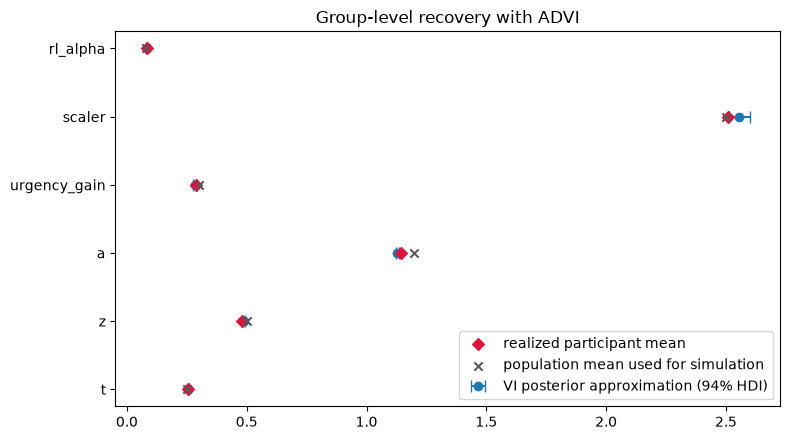

,mean,hdi94_lb,hdi94_ub,realized_mean,population_mean
rl_alpha,0.082,0.078,0.086,0.082,0.08
scaler,2.553,2.511,2.600,2.508,2.50
urgency_gain,0.283,0.276,0.291,0.288,0.30
a,1.128,1.121,1.134,1.143,1.20
z,0.489,0.486,0.493,0.482,0.50
t,0.256,0.253,0.258,0.255,0.25


In [14]:
group_summary = group_recovery(idata, GROUP_THETA, true_params)
group_summary[["mean", "hdi94_lb", "hdi94_ub", "realized_mean", "population_mean"]].round(3)

### 9.2 Participant-level recovery

Each point reconstructs a participant's parameter as `Intercept + deviation` and
compares it with that participant's simulation truth. In this example the ADVI fit is
fast enough that we can use many trials per participant, which gives the model a clear
learning history for estimating individual differences.

The points should not be interpreted as exact posterior calibration. VI is optimized to
be close to the posterior within a restricted family of distributions, and mean-field
ADVI in particular cannot represent every posterior dependence. The plot is best read
as a practical check: does the approximate fit recover the ordering and approximate
magnitude of the participant-level parameters?

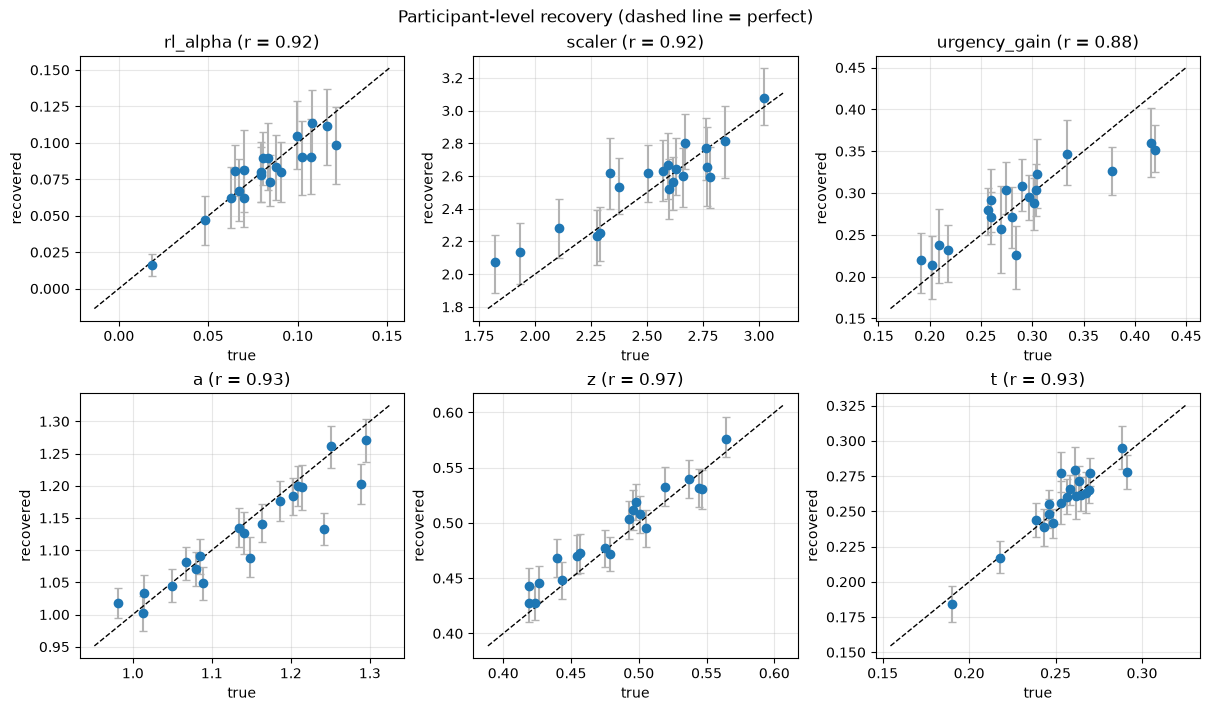

participant correlations:
rl_alpha        0.92
scaler          0.92
urgency_gain    0.88
a               0.93
z               0.97
t               0.93
ADVI loss: 15338.3 -> 13215.0
Note: VI draws do not provide MCMC r-hat or divergence diagnostics; use loss behavior, recovery checks, PPCs, and sensitivity checks instead.


In [15]:
participant_correlations = participant_recovery(idata, true_params)

print("participant correlations:")
print(participant_correlations.round(2).to_string())
print(
    "ADVI loss: "
    f"{float(model.vi_approx.hist[0]):.1f} -> {float(model.vi_approx.hist[-1]):.1f}"
)
print(
    "Note: VI draws do not provide MCMC r-hat or divergence diagnostics; "
    "use loss behavior, recovery checks, PPCs, and sensitivity checks instead."
)

## 10. Posterior predictive checks

A posterior predictive check (PPC) asks whether the fitted parameters can regenerate
the behavioral patterns in the observed data. RLSSMs need care because every choice
and reward changes the learner's future state.

`ssms.rl` provides `mode="ppc"` for exactly this. It **replays each participant's
observed responses and feedback** when updating Q-values, so the predicted `v` and
`theta` trajectories follow the history that was actually observed. The choice and RT
on each trial are then **newly simulated** from a posterior parameter draw. This tests
the decision model along a comparable learning path rather than inventing a second,
unrelated reward history.

We draw several complete posterior samples. Each sample holds a coherent set of all
six parameters for every participant; mixing values across draws would destroy
posterior correlations. The helper rebuilds natural-scale participant values as
`Intercept + deviation`.

In [16]:
def draw_posterior_theta(idata, sample_idx):
    "Return one coherent posterior draw of every free participant parameter."
    posterior = idata.posterior
    if hasattr(posterior, "to_dataset"):
        posterior = posterior.to_dataset()  # PyMC 6 returns a DataTree node
    posterior = posterior.stack(sample=("chain", "draw"))
    theta = {}
    for name in LIST_PARAMS:
        effect = posterior[f"{name}_1|participant_id"]
        participant_dim = [dim for dim in effect.dims if dim != "sample"][0]
        values = (posterior[f"{name}_Intercept"] + effect).isel(sample=sample_idx)
        participant_ids = [int(value) for value in effect[participant_dim].values]
        ordered = pd.Series(
            np.asarray(values.values), index=participant_ids
        ).sort_index()
        theta[name] = ordered.reindex(range(N_PARTICIPANTS)).to_numpy()
    return theta


n_posterior_samples = idata.posterior.sizes["chain"] * idata.posterior.sizes["draw"]
ppc_rng = np.random.default_rng(RANDOM_SEED + 1)
sample_ids = ppc_rng.choice(
    n_posterior_samples,
    size=min(N_PPC_DRAWS, n_posterior_samples),
    replace=False,
)

ppc_frames = []
for ppc_draw, sample_idx in enumerate(sample_ids):
    theta_draw = draw_posterior_theta(idata, int(sample_idx))
    simulated = rl.Simulator(ssms_config).simulate(
        theta=theta_draw,
        mode="ppc",
        observed_data=data,
        random_state=RANDOM_SEED + 100 + ppc_draw,
    )
    simulated["ppc_draw"] = ppc_draw
    ppc_frames.append(simulated)

ppc_data = pd.concat(ppc_frames, ignore_index=True)
print(
    f"PPC datasets: {len(sample_ids)} | rows per dataset: {len(data)} | "
    f"total rows: {len(ppc_data)}"
)

PPC datasets: 20 | rows per dataset: 20000 | total rows: 400000


### 10.1 Observed vs. predicted learning curve

Option `0` maps to response `-1` and is the high-reward option. The observed black
line and the posterior-predictive blue line (with a 94% band across replicated
datasets) should climb together from chance toward a preference for the high-reward
option. A model that reproduces the learning curve has captured the drift side of the
coupling.

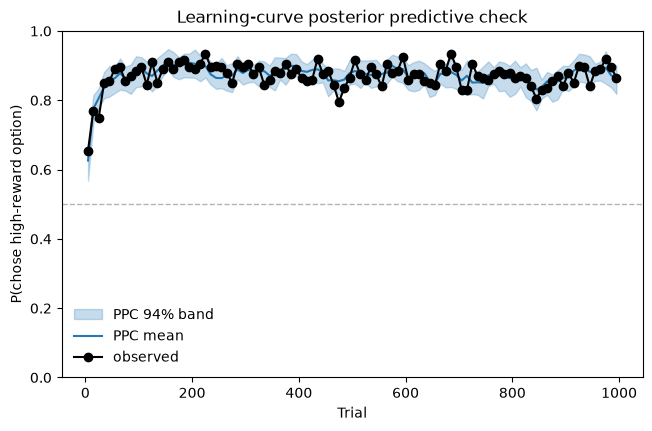

In [17]:
def binned_choice_curve(dataframe, include_draw=False, bin_size=10):
    "Summarize high-reward choices by within-participant trial bin."
    valid = dataframe[
        np.isfinite(dataframe["rt"])
        & (dataframe["rt"] > 0)
        & (dataframe["response"] > -900)
    ].copy()
    valid["chose_high"] = (valid["response"] == -1).astype(float)
    valid["trial_bin"] = (valid["trial_id"] // bin_size) * bin_size
    group_columns = ["trial_bin"]
    if include_draw:
        group_columns = ["ppc_draw", "trial_bin"]
    return (
        valid.groupby(group_columns, observed=True)["chose_high"]
        .mean()
        .reset_index()
    )


observed_curve = binned_choice_curve(data).set_index("trial_bin")["chose_high"]
predicted_curve = (
    binned_choice_curve(ppc_data, include_draw=True)
    .pivot(index="trial_bin", columns="ppc_draw", values="chose_high")
    .sort_index()
)
curve_centers = predicted_curve.index + BIN_SIZE / 2

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.fill_between(
    curve_centers,
    predicted_curve.quantile(0.03, axis=1),
    predicted_curve.quantile(0.97, axis=1),
    color="tab:blue",
    alpha=0.25,
    label="PPC 94% band",
)
ax.plot(curve_centers, predicted_curve.mean(axis=1), color="tab:blue", lw=1.5,
        label="PPC mean")
ax.plot(observed_curve.index + BIN_SIZE / 2, observed_curve.values, "o-",
        color="black", label="observed")
ax.axhline(0.5, color="0.7", ls="--", lw=1)
ax.set_ylim(0, 1)
ax.set_xlabel("Trial")
ax.set_ylabel("P(chose high-reward option)")
ax.set_title("Learning-curve posterior predictive check")
ax.legend(frameon=False)
plt.show()

### 10.2 Signed response times

Signed RT places both outcomes on one axis: negative values are the high-reward
response (`-1`), positive values the lower-reward response (`1`). This single view
checks the response proportions and the RT distribution together. Because `theta`
grows with learning, the model's boundary collapses faster on later trials — a
behavioral fingerprint the PPC should reproduce alongside the observed outline.

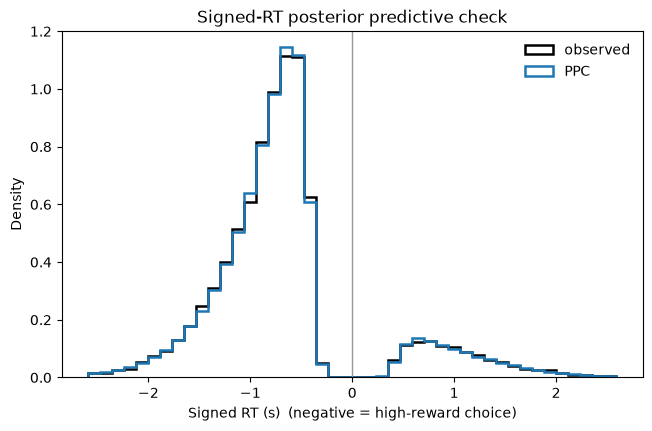

In [18]:
def signed_rt(dataframe):
    "Return finite RTs signed by response (- = high reward, + = low reward)."
    valid = dataframe[
        np.isfinite(dataframe["rt"])
        & (dataframe["rt"] > 0)
        & (dataframe["response"] > -900)
    ]
    return np.where(
        valid["response"].astype(int) == -1,
        -valid["rt"].astype(float),
        valid["rt"].astype(float),
    )


all_signed_rt = np.concatenate([signed_rt(data), signed_rt(ppc_data)])
rt_limit = np.quantile(np.abs(all_signed_rt), 0.995)
bins = np.linspace(-rt_limit, rt_limit, 45)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(signed_rt(data), bins=bins, density=True, histtype="step", lw=1.8,
        color="black", label="observed")
ax.hist(signed_rt(ppc_data), bins=bins, density=True, histtype="step", lw=1.8,
        color="tab:blue", label="PPC")
ax.axvline(0, color="0.6", lw=1)
ax.set_xlabel("Signed RT (s)  (negative = high-reward choice)")
ax.set_ylabel("Density")
ax.set_title("Signed-RT posterior predictive check")
ax.legend(frameon=False)
plt.show()

## 11. Summary

You have fitted an RLSSM in which **one learning process drives two decision
parameters**:

1. **Multiple computed outputs:** `DualOutputRWLearner` declares
   `computed_params = ["drift", "urgency"]` and computes both every trial from the same
   Q-values.
2. **Explicit routing:** `computed_param_mapping = {"drift": "v", "urgency": "theta"}`
   sends each output to a named SSM parameter, so `v` **and** `theta` are learner-
   computed and neither is sampled.
3. **A visible restless signature:** replaying the learning history shows the drift
   moving away from zero and the angle parameter `theta` climbing over trials — two
   parameters moving together on the slow timescale.
4. **The same downstream workflow:** the `RLSSMConfig.from_ssms_model` bridge,
   mean-zero hierarchical priors, and RLSSM-aware `mode="ppc"` posterior predictive
   simulation carry over unchanged.
5. **A VI-based fit:** HSSM's `model.vi(...)` interface lets us fit the same RLSSM with
   PyMC's variational inference machinery. The result is fast enough for a rich
   tutorial-scale example with many trials per participant.

**Caveats about VI.** Variational inference is an approximation to Bayesian inference,
not a free replacement for MCMC. It is fast and memory-efficient because it turns
inference into optimization over a restricted family of distributions. That restriction
is also the main drawback. ADVI, especially mean-field ADVI, often **underestimates
posterior uncertainty**, can miss posterior correlations, can settle into a local
optimum, and can make intervals look more precise than the data really justify. Loss
curves are useful, but they are not the same as MCMC diagnostics such as r-hat,
effective sample size, or divergences.

For that reason, use VI with care and caution. It is valuable for quick model checks,
large exploratory fits, posterior predictive demonstrations, and situations where MCMC
is too slow for the immediate goal. When calibrated uncertainty is the scientific
quantity of interest, compare against MCMC on smaller versions of the model, run
sensitivity checks with different priors/starts/optimizers, inspect PPCs, and be direct
about the approximate nature of the posterior. In this tutorial, VI is used to show
that HSSM can fit this flexible RLSSM efficiently; it is not presented as the final word
on uncertainty calibration for this coupled model.

Continue with [HSSM-native custom model registration](rlssm_hssm_custom_models.ipynb)
for the shortest customization path, or revisit
[building a custom `ssms.rl` model](rlssm_advanced.ipynb) and
[RLSSM basics](rlssm_basic.ipynb).